In [1]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("truonglongty/chest-xray-dataset")

# print("Path to dataset files:", path)

In [2]:
# Cell 1: Setup - Fix CUDA cho MobileNetV3
import os
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")

# Fix CUDA
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Using device: cuda


Cấu trúc thư mục:
/kaggle/input/datasets/truonglongty/chest-xray-dataset/initial_training/val/Effusion - 480 files
/kaggle/input/datasets/truonglongty/chest-xray-dataset/initial_training/val/Infiltration - 430 files
/kaggle/input/datasets/truonglongty/chest-xray-dataset/initial_training/val/No Finding - 440 files
/kaggle/input/datasets/truonglongty/chest-xray-dataset/initial_training/val/Atelectasis - 412 files
/kaggle/input/datasets/truonglongty/chest-xray-dataset/initial_training/test/Effusion - 441 files
/kaggle/input/datasets/truonglongty/chest-xray-dataset/initial_training/test/Infiltration - 414 files
/kaggle/input/datasets/truonglongty/chest-xray-dataset/initial_training/test/No Finding - 424 files
/kaggle/input/datasets/truonglongty/chest-xray-dataset/initial_training/test/Atelectasis - 416 files
/kaggle/input/datasets/truonglongty/chest-xray-dataset/initial_training/train/Effusion - 1879 files
/kaggle/input/datasets/truonglongty/chest-xray-dataset/initial_training/train/Infilt

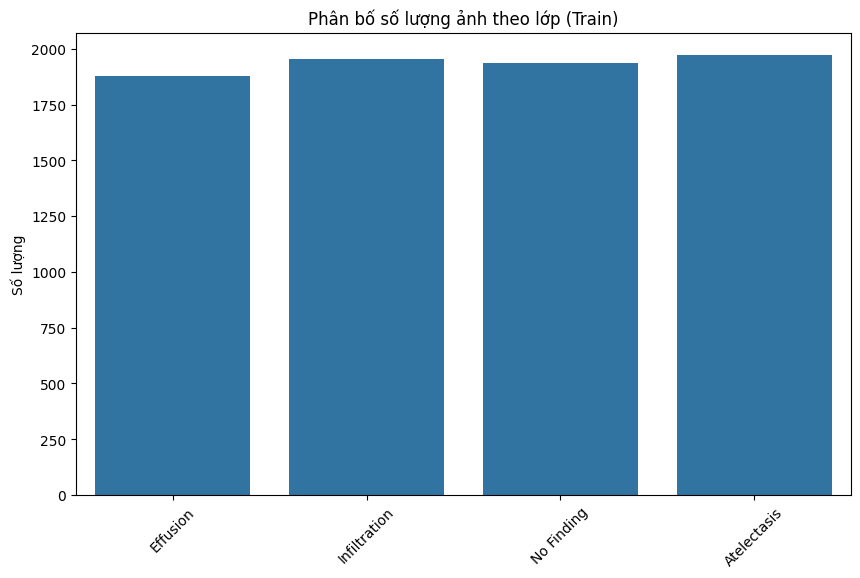

In [3]:
# Cell 2: EDA
DATA_ROOT = "/kaggle/input/datasets/truonglongty/chest-xray-dataset/initial_training"

print("Cấu trúc thư mục:")
for dirpath, dirnames, filenames in os.walk(DATA_ROOT):
    if len(filenames) > 0:
        print(f"{dirpath} - {len(filenames)} files")

train_dir = f"{DATA_ROOT}/train"
val_dir   = f"{DATA_ROOT}/val"
test_dir  = f"{DATA_ROOT}/test"

def count_images(folder):
    counts = {}
    for cls in os.listdir(folder):
        if os.path.isdir(os.path.join(folder, cls)):
            counts[cls] = len(os.listdir(os.path.join(folder, cls)))
    return counts

print("\nTrain set:", count_images(train_dir))
print("Val set:  ", count_images(val_dir))
print("Test set: ", count_images(test_dir))

# Vẽ biểu đồ phân bố
counts = count_images(train_dir)
plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts.keys()), y=list(counts.values()))
plt.title("Phân bố số lượng ảnh theo lớp (Train)")
plt.xticks(rotation=45)
plt.ylabel("Số lượng")
plt.show()

In [4]:
# Cell 3: Transforms & Dataset
CLASSES = ["Atelectasis", "Effusion", "Infiltration", "No_Finding"]
NUM_CLASSES = len(CLASSES)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAdjustSharpness(2, p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = ImageFolder(root=train_dir, transform=train_transform)
val_dataset   = ImageFolder(root=val_dir,   transform=val_transform)
test_dataset  = ImageFolder(root=test_dir,  transform=val_transform)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")
print(f"Test samples:  {len(test_dataset)}")
print("Class to idx:", train_dataset.class_to_idx)

Train samples: 7743
Val samples:   1762
Test samples:  1695
Class to idx: {'Atelectasis': 0, 'Effusion': 1, 'Infiltration': 2, 'No Finding': 3}


In [5]:
# Cell 4: DataLoader
batch_size = 32   # Giảm mạnh để tránh OOM + CUDA error

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
                         num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, 
                         num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, 
                         num_workers=4, pin_memory=True)

In [6]:
# Cell 5: MobileNetV3-Small
def get_model():
    # Dùng weights ổn định hơn
    weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
    model = models.mobilenet_v3_small(weights=weights)
    
    in_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.Hardswish(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(512, NUM_CLASSES)
    )
    return model

model = get_model().to(device)
print("✅ MobileNetV3-Small loaded successfully!")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 105MB/s]


✅ MobileNetV3-Small loaded successfully!


In [7]:
# Cell 6: TRAINING LOOP - TỐI ƯU (Early Stopping + Scheduler) - ĐÃ FIX
epochs = 40
lr = 1e-3
patience = 8          
min_delta = 0.001     

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

# Scheduler (đã bỏ verbose)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=4
)

best_acc = 0.0
best_epoch = 0
early_stop_counter = 0

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Bắt đầu huấn luyện với\n")

for epoch in range(epochs):
    # ====================== TRAINING ======================
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_acc = correct / total
    train_loss = train_loss / len(train_loader)
    
    # ====================== VALIDATION ======================
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    val_acc = correct / total
    val_loss = val_loss / len(val_loader)
    
    # Lưu history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Scheduler step theo val_acc
    scheduler.step(val_acc)
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:2d} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
          f"LR: {current_lr:.6f}")
    
    # Save best model
    if val_acc > best_acc + min_delta:
        best_acc = val_acc
        best_epoch = epoch
        early_stop_counter = 0
        
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'classes': CLASSES
        }, "best_model.pth")
        print(f"✅ Best model updated! Val Acc = {best_acc:.4f}")
    else:
        early_stop_counter += 1
    
    # Early Stopping
    if early_stop_counter >= patience:
        print(f"\n🛑 Early Stopping! Không cải thiện sau {patience} epoch.")
        print(f"Best epoch: {best_epoch} - Val Acc: {best_acc:.4f}")
        break

print(f"\nHoàn thành huấn luyện! Best Validation Accuracy: {best_acc:.4f}")

Bắt đầu huấn luyện với



Epoch 1/40 [Val]: 100%|██████████| 56/56 [00:16<00:00,  3.39it/s]


Epoch  1 | Train Loss: 1.2282 Acc: 0.4341 | Val Loss: 1.2043 Acc: 0.4574 | LR: 0.001000
✅ Best model updated! Val Acc = 0.4574


Epoch 2/40 [Val]: 100%|██████████| 56/56 [00:14<00:00,  3.90it/s]


Epoch  2 | Train Loss: 1.1454 Acc: 0.4908 | Val Loss: 1.3270 Acc: 0.4313 | LR: 0.001000


...

Epoch 17 | Train Loss: 0.7184 Acc: 0.7048 | Val Loss: 1.3703 Acc: 0.5068 | LR: 0.000250


Epoch 18/40 [Val]: 100%|██████████| 56/56 [00:14<00:00,  3.94it/s]


Epoch 18 | Train Loss: 0.6907 Acc: 0.7070 | Val Loss: 1.3900 Acc: 0.4932 | LR: 0.000250


Epoch 19/40 [Val]: 100%|██████████| 56/56 [00:14<00:00,  3.92it/s]

Epoch 19 | Train Loss: 0.6564 Acc: 0.7323 | Val Loss: 1.3832 Acc: 0.5108 | LR: 0.000250

🛑 Early Stopping! Không cải thiện sau 8 epoch.
Best epoch: 10 - Val Acc: 0.5420

Hoàn thành huấn luyện! Best Validation Accuracy: 0.5420


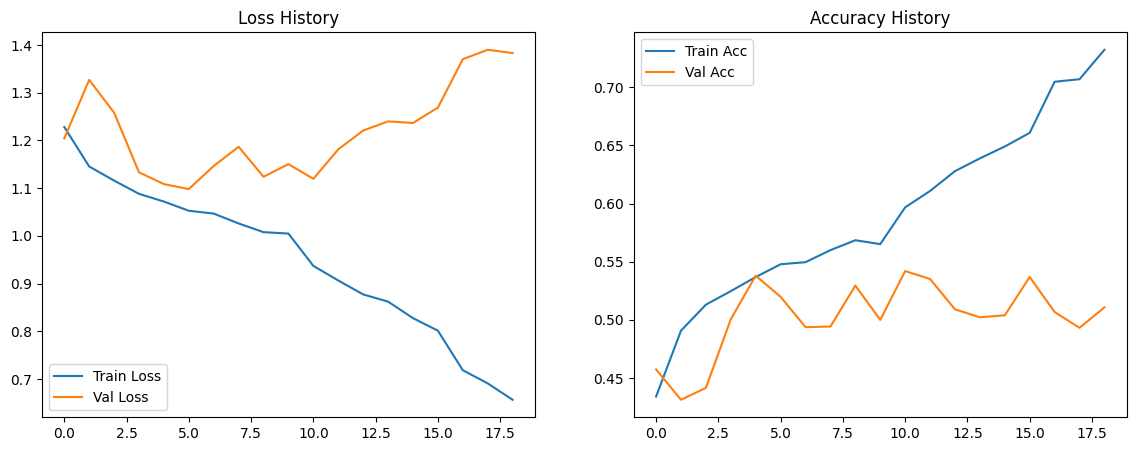

In [8]:
# Cell 7: Training History
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy History')
plt.legend()

plt.show()

In [9]:
# Cell 8: ĐÁNH GIÁ TOÀN DIỆN TRÊN TEST SET
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating on Test Set"):
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# ====================== TÍNH METRICS ======================
accuracy = accuracy_score(all_labels, all_preds)
precision_macro = precision_score(all_labels, all_preds, average='macro')
recall_macro = recall_score(all_labels, all_preds, average='macro')
f1_macro = f1_score(all_labels, all_preds, average='macro')

precision_weighted = precision_score(all_labels, all_preds, average='weighted')
recall_weighted = recall_score(all_labels, all_preds, average='weighted')
f1_weighted = f1_score(all_labels, all_preds, average='weighted')

print("="*60)
print("📊 TEST SET EVALUATION")
print("="*60)
print(f"Accuracy          : {accuracy:.4f}")
print(f"Precision (Macro) : {precision_macro:.4f}")
print(f"Recall (Macro)    : {recall_macro:.4f}")
print(f"F1-Score (Macro)  : {f1_macro:.4f}")
print(f"Precision (Weighted): {precision_weighted:.4f}")
print(f"Recall (Weighted) : {recall_weighted:.4f}")
print(f"F1-Score (Weighted): {f1_weighted:.4f}")
print("="*60)

# Classification Report chi tiết
print("\nClassification Report (Per Class):")
print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))

# Lưu metrics vào DataFrame để dễ xem
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)',
               'Precision (Weighted)', 'Recall (Weighted)', 'F1-Score (Weighted)'],
    'Score': [accuracy, precision_macro, recall_macro, f1_macro,
              precision_weighted, recall_weighted, f1_weighted]
})
display(metrics_df.round(4))

Evaluating on Test Set: 100%|██████████| 53/53 [00:15<00:00,  3.32it/s]

📊 TEST SET EVALUATION
Accuracy          : 0.5009
Precision (Macro) : 0.5005
Recall (Macro)    : 0.4996
F1-Score (Macro)  : 0.4999
Precision (Weighted): 0.5020
Recall (Weighted) : 0.5009
F1-Score (Weighted): 0.5013

Classification Report (Per Class):
              precision    recall  f1-score   support

 Atelectasis     0.5463    0.5529    0.5496       416
    Effusion     0.6115    0.6032    0.6073       441
Infiltration     0.3899    0.4106    0.4000       414
  No_Finding     0.4541    0.4316    0.4426       424

    accuracy                         0.5009      1695
   macro avg     0.5005    0.4996    0.4999      1695
weighted avg     0.5020    0.5009    0.5013      1695



,Metric,Score
0,Accuracy,0.5009
1,Precision (Macro),0.5005
2,Recall (Macro),0.4996
3,F1-Score (Macro),0.4999
4,Precision (Weighted),0.5020
5,Recall (Weighted),0.5009
6,F1-Score (Weighted),0.5013


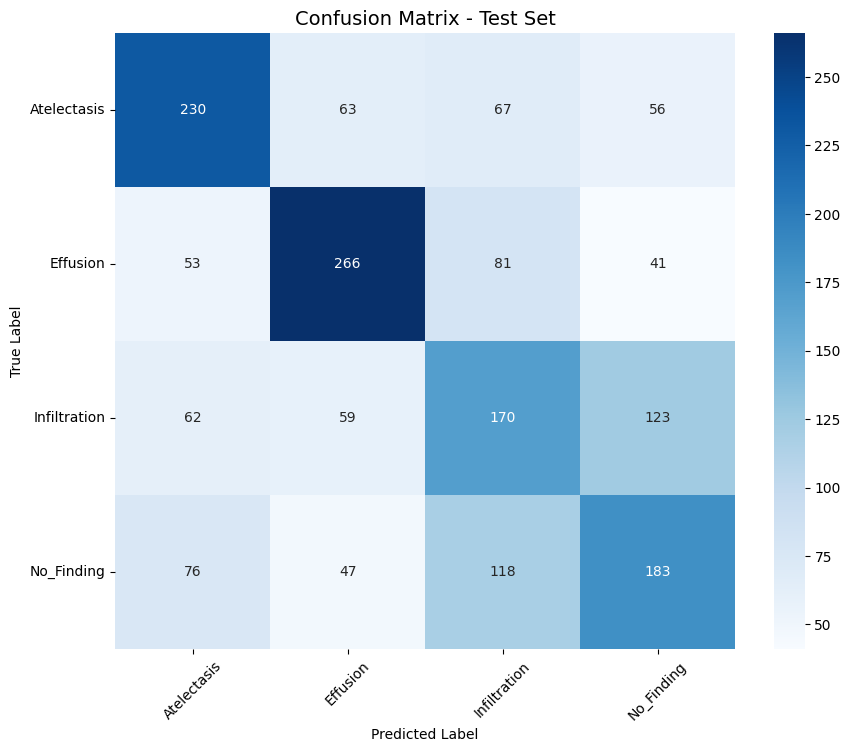

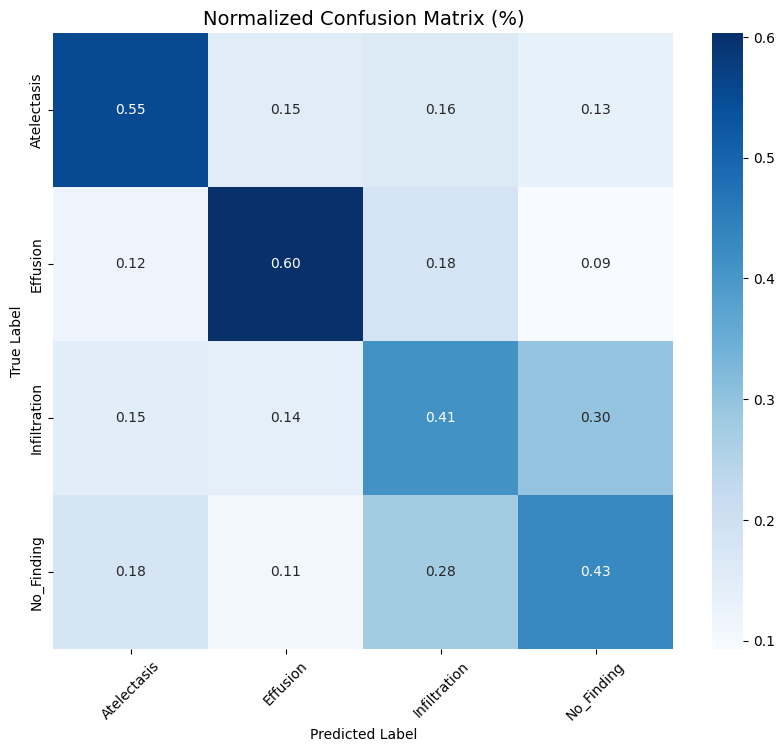

In [10]:
# Cell 9: Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix - Test Set', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# Normalized Confusion Matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Normalized Confusion Matrix (%)', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.show()